=================================================

    Live Code 3

    Nama  : Ali Abdurrahman
    Batch : HCK-30

    Program ini dibuat untuk melacak outlier dalam sebuah kolom data dan menghapusnya, lalu menghasilkan csv yang bersih dari outlier dan mengaplikasikannya ke API.
=================================================

In [1]:
from google.colab import auth
from google.cloud import bigquery
auth.authenticate_user()
print('Authenticated')

project_id_akun = "hacktiv8-464809" # Gunakan GCP Project-ID Anda
client = bigquery.Client(project=project_id_akun)

Authenticated


In [2]:

query = """
SELECT state_bottle_retail
FROM `bigquery-public-data.iowa_liquor_sales.sales`
WHERE vendor_name = 'SAZERAC COMPANY  INC'
LIMIT 5000
"""

# retrieve data from query and convert it into dataframe
df = client.query(query).to_dataframe()

# print the dataframe
df

,state_bottle_retail
0,10.59
1,10.38
2,3.75
3,1.50
4,17.63
...,...
4995,6.45
4996,6.56
4997,6.45
4998,6.54


1.  Central Tendency (Mean, Median, dan Modus)

In [3]:
import pandas as pd
"""Kita mencari Centran Tendenct Statistik dahulu, yaitu mean, median, modus"""
mean = df['state_bottle_retail'].mean()
median = df['state_bottle_retail'].median()
modus = df['state_bottle_retail'].mode()[0]

print(f"Mean: {mean}")
print(f"Median: {median}")
print(f"Modus: {modus}")

Mean: 28.916030000000006
Median: 13.18
Modus: 77.4


2. Cek skewness

In [4]:
"""mengambil data dari kolom state_bottle_retail dan menghitung langsung nilai skew nya"""
skew = df['state_bottle_retail'].skew()

print(f"Skew: {skew}")

Skew: 1.1193425243804196


Disini sudah terlihat bahwa skew positif. Artinya persebaran data ada outlier dan cenderung mengekor panjang ke kanan

In [5]:
"""Melacak outlier menggunakan metode IQR"""
"""Hitung Quartil 1 dan Quartil 3"""
Q1 = df['state_bottle_retail'].quantile(0.25)
Q3 = df['state_bottle_retail'].quantile(0.75)

"""Menghitung range IQR yang nantinya digunakan untuk menetapkan batas atas dan bawah"""
IQR = Q3 - Q1

"""Menetapkan batas atas dan bawah, yang diluar batas ini nantinya di singkirkan"""
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#  outlier
"""Melacak baris data yang termasuk outlier (diluar batas IQR)"""
outliers = df[(df['state_bottle_retail'] < lower_bound) | (df['state_bottle_retail'] > upper_bound)]

"""Menyimpan data hasil pembersihan outlier (yang berada di dalam IQR)"""
clean_df = df[(df['state_bottle_retail'] >= lower_bound) & (df['state_bottle_retail'] <= upper_bound)]

# Persentase outlier
"""Menghitung total persen outlier berdasarkan jumlah data
"""
persentase_outlier = (len(outliers) / len(df)) * 100 #Banyaknya outliers dibagi banyaknya nilai di kolom df menghasilkan persentase

"""Menampilkan Hasil"""
print(f"banyaknya outliers: {len(outliers)}")
print(f"banyaknya data setelah dibersihkan dari outliers:{len(clean_df)}")

print(f"Persentase outlier: {persentase_outlier:.2f}%")

banyaknya outliers: 18
banyaknya data setelah dibersihkan dari outliers:4982
Persentase outlier: 0.36%


*Persentase outlier 0.36% yang artinya kecil (sedikit)

In [6]:
"""Mendownload hasil data yang sudah dibersihkan. Data nantinya akan dipakai untuk di API"""
from google.colab import files
clean_df.to_csv("Data_Clean.csv", index=False)
files.download("Data_Clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

3. Analisis

Section 3 - Data Analysis

Jawablah pertanyaan-pertanyaan dibawah ini berdasarkan hasil yang Anda peroleh sebelumnya. Anda dapat menggunakan Markdown untuk memperjelas jawaban Anda.

1. Berapa nilai rata-rata, median, dan modus dari data yang Anda peroleh sebelum dihilangkan outliernya ? Bagaimana kecenderungan pemusatan datanya ? Jelaskan analisa Anda !

2. Berdasarkan nilai skewness yang Anda peroleh, bagaimana dengan distribusi datanya? Jelaskan analisa Anda !

3. Ada dua teknik yang dapat dipakai untuk melakukan Extreme Value Analysis. Teknik manakah yang Anda pakai ? Berikan alasan Anda memakainya dengan berdasarkan data !

Jawab:
1. Mean jauh lebih besar daripada median. Artinya sebagian besar harga berada di rentang bawah, tapi ada beberapa harga tinggi (outlier) yang membuat nilai rata-rata menjadi naik secara ekstrem

2. Nilai skew posiif (1,119), artinya ekor distribusi cenderung ke kanan dan cenderung banyak nilai rendah di sisi kurva
Atau jika di intpretasikan visualisasi distribusi datanya, ada beberapa nilai harga yang sangat tinggi yang akibatnya menarik rata-rata data ke kanan. (Misal jika dibayangkan memakai histogram, data yang bernilai tinggi akan menjurus sangat ke kanan di sumbu X, itu menyebabkan persebaran data ekstrem mengekor ke kanan)

3. Saya memakai IQR. Karena lebih aman terhadap data yang terdapat outlier dan membagi rentang data 50% (setengahnya di bagian tengah) sehingga lebih stabil pemakaian metodenya. Dan juga sebelum membersihkan outlier, sudah ketahuan bahwa distibusi data ekstrem ke kanan dengan bukti skew sebesar 1.1 (skew positif)

    IQR mendeteksi nilai-nilai outlier dengan menetapkan batas bawah dan atas (Lower dan Upper Bound). Setiap data yang berada di luar batas yang telah di hitung akan dianggap sebagai outlier dan dibersihkan dari database

Untuk memperjelas penjelasan di nomor dua, saya beri visualisasi datanya biar mudah di bayangkan:

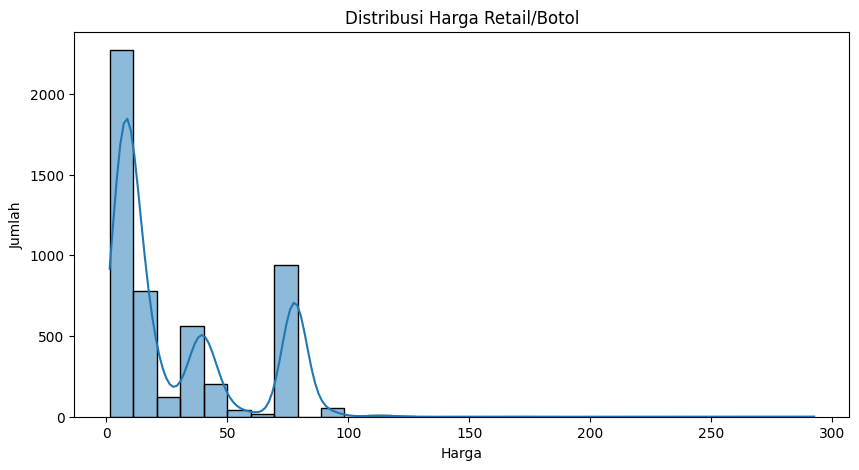

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['state_bottle_retail'], bins=30, kde=True)
plt.title("Distribusi Harga Retail/Botol")
plt.xlabel("Harga")
plt.ylabel("Jumlah")
plt.show()